In [117]:
import pandas as pd

In [ ]:
df = pd.read_csv("Reviews5000.csv")

In [93]:
print(df.shape) #(rows,columns)

(5000, 10)


In [94]:
df.head(10) #first 10 datasets

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [95]:
df.tail(10)  #last 10 datasets

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
4990,4991,B004TTSB2C,A3DMQM4OQONEMK,Jazzy,0,0,5,1351036800,Love em'!,They are awesome to snack on. They have a lit...
4991,4992,B004TTSB2C,A2YMS9UK1A9OF2,Jeff,0,0,5,1343088000,totally Ginger!,Reed's Crystallized Ginger is the real deal! I...
4992,4993,B002Z9NKUG,A1Z4LX3Q1YMF84,"Cindy A. Osterhout ""Cindy O""",0,0,2,1346112000,INDIGESTION OF MAJOR PROPORTIONS,I have one cat who cannot tolerate THIS PARtic...
4993,4994,B000FA398U,A1Z54EM24Y40LL,c2,3,3,5,1203206400,Best for oyster soup!,Try these first for all your seafood soups and...
4994,4995,B00653KJ5M,AZLTR11CYKN5V,RyanTheLion,4,4,5,1322784000,AMAZING!,If you are on the paleo/caveman/primal/hunter-...
4995,4996,B00653KJ5M,AGE64SY3HP9RV,CZ,1,1,2,1341273600,The cavemen must have been wealthy,I really wanted to like these.<br /><br />Firs...
4996,4997,B00653KJ5M,A1MPEPNJ2NKWM,Rachel Albert Matesz,1,1,1,1341100800,These cookies need work; you can make your own...,I was not impressed with these cookies when I ...
4997,4998,B00653KJ5M,A1T6I625FGQS20,IL,1,1,3,1336694400,Okay in a pinch - not great,The cookies came sealed and seem to be high qu...
4998,4999,B00653KJ5M,A3POAWC2JPQQQP,me,0,0,4,1342137600,"they are good (except for the ""rainforest"" fla...","These taste very good, but aren't like the BES..."
4999,5000,B00653KJ5M,A122CSYJ3YSKI0,Shaimun,0,0,5,1337990400,Great Healthy Snack!,I love these cookies. I am on the paleo diet r...


In [96]:
df = df[["Text","Score"]]

In [98]:
df.isna().sum()  #No blank text or null score

Text     0
Score    0
dtype: int64

In [99]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
5       False
6       False
7       False
8       False
9       False
10      False
11      False
12      False
13      False
14      False
15      False
16      False
17      False
18      False
19      False
20      False
21      False
22      False
23      False
24      False
25      False
26      False
27      False
28      False
29       True
30      False
31      False
32      False
33      False
34      False
35      False
36      False
37      False
38      False
39      False
40      False
41      False
42      False
43      False
44      False
45      False
46      False
47      False
48      False
49      False
50      False
51      False
52      False
53      False
54      False
55      False
56      False
57      False
58      False
59      False
60      False
61      False
62      False
63      False
64      False
65      False
66      False
67      False
68      False
69      False
70      False
71    

In [100]:
df.duplicated(subset=["Text"]).sum()

np.int64(16)

In [101]:
df = df.drop_duplicates(subset=["Text"])

In [102]:
df.duplicated(subset=["Text"]).sum()

np.int64(0)

In [103]:
df.shape

(4984, 2)

In [2]:
#Sentiment Analysis
from textblob import TextBlob

In [105]:
df["Polarity"]= df["Text"].apply(lambda x: TextBlob(x).sentiment.polarity)

In [106]:
def get_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

In [107]:
df["sentiment"]= df["Polarity"].apply(get_sentiment)

In [108]:
df.head(5)

,Text,Score,Polarity,sentiment
0,I have bought several of the Vitality canned d...,5,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333,Negative
2,This is a confection that has been around a fe...,4,0.133571,Positive
3,If you are looking for the secret ingredient i...,2,0.166667,Positive
4,Great taffy at a great price. There was a wid...,5,0.483333,Positive


In [109]:
import matplotlib.pyplot as plt

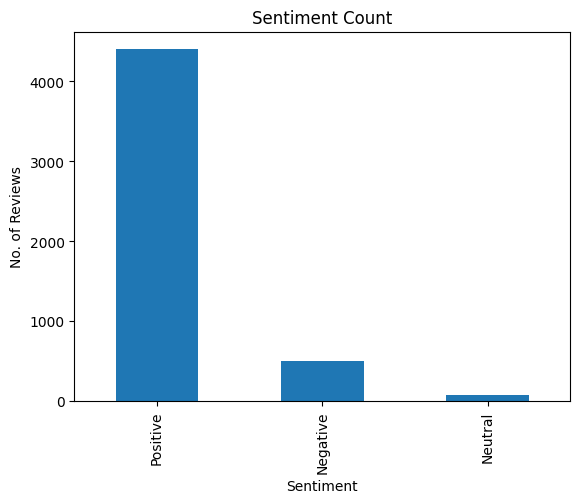

In [110]:
#bar chart
df["sentiment"].value_counts().plot(kind= "bar")
plt.title("Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("No. of Reviews")
plt.show()

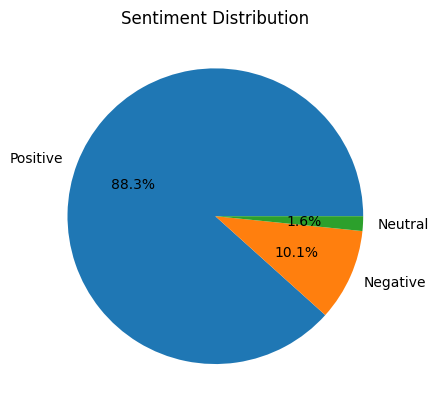

In [111]:
#pie chart
df["sentiment"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.show()

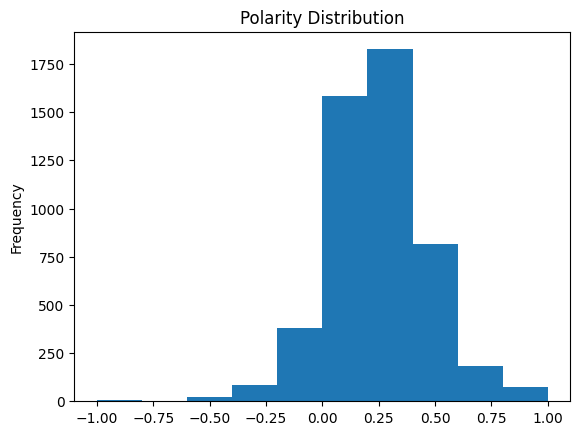

In [112]:
#polarity distribution
df["Polarity"].plot(kind="hist")
plt.title("Polarity Distribution")
plt.show()

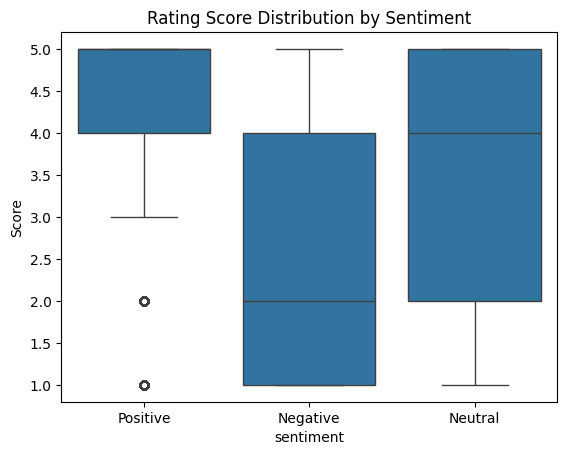

In [113]:
import seaborn as sns

sns.boxplot(x="sentiment", y="Score", data=df)
plt.title("Rating Score Distribution by Sentiment")
plt.show()

In [114]:
negative_df = df[df["sentiment"] == "Negative"][["sentiment","Text"]]

In [115]:
pd.set_option('display.max_rows', None)
negative_df.sample(20)

,sentiment,Text
4392,Negative,Apparently 'regular' size = thinner than stand...
3036,Negative,"I love these cookies, they taste exactly like ..."
1076,Negative,Nature's Recipe is now a division of that mega...
1477,Negative,"This coffee supposedly is premium, it tastes w..."
561,Negative,The chips were great...for the first few bags....
4148,Negative,Shipping: Ordered on a Sunday of Week 1. Plac...
4833,Negative,I have a 3 year old Boston Terrier who is not ...
4918,Negative,I bought this tea during a major sinus infecti...
813,Negative,"Trident ""Strawberry Twist"" sugarless gum is ve..."
4762,Negative,I had to pick up a grocery store brand after r...


# Insights & Summary

### -The majority of reviews are positive, with about 88.3% of customers giving good feedback.
### -The overall sentiment shows that most customers are satisfied with the product.
### -The negative reviews, around 10.1%, mainly mention issues like poor quality, stale items, wrong deliveries, and stock problems.
### -The polarity distribution also supports that most feedback is on the positive side.
### -The interesting part is that sometimes ratings and written reviews do not fully match.
### -The overall data suggests that the product is liked but has some recurring issues.
### -The business should focus on improving quality, delivery accuracy, and stock management.
### -These improvements can help reduce negative reviews and increase customer satisfaction.